In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

C:\Users\Nikon\AppData\Local\Temp\ipykernel_2628\3632617853.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


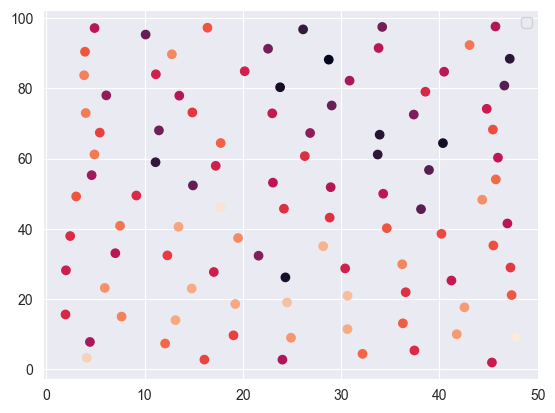

In [46]:
height, width = (50, 100)

points = np.random.random((2, 100))
points[0, :] *= width
points[1, :] *= height

moved_points = []

for t in range(100):

    reflected_points = []

    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            this_points = points.copy()
            if i == -1:
                this_points[0, :] = -this_points[0, :]

            elif i == 1:
                this_points[0, :] = -this_points[0, :] + width*2

            if j == -1:
                this_points[1, :] = -this_points[1, :]

            elif j == 1:
                this_points[1, :] = -this_points[1, :] + height*2

            reflected_points.append(this_points)

    reflected_points = np.concatenate(reflected_points, axis=1)

    dx = 0.1

    pos_dy_points = points + np.array([dx, 0])[:, None]
    neg_dy_points = points + np.array([-dx, 0])[:, None]

    pos_dx_points = points + np.array([0, dx])[:, None]
    neg_dx_points = points + np.array([0, -dx])[:, None]

    sigma = 5.0

    def gauss(p):
        dist = cdist(p.T, reflected_points.T)
        gauss_kernel = 1 / np.sqrt(2 * sigma ** 2 * np.pi) * np.exp(-1 / 2 * dist ** 2 / sigma ** 2)
        density = np.sum(gauss_kernel, axis = 1)
        return density

    pos_dy_density = gauss(pos_dy_points)
    neg_dy_density = gauss(neg_dy_points)
    pos_dx_density = gauss(pos_dx_points)
    neg_dx_density = gauss(neg_dx_points)

    gradient_y = (pos_dy_density - neg_dy_density) / (2 * dx)
    gradient_x = (pos_dx_density - neg_dx_density) / (2 * dx)

    gradient = np.stack([gradient_y, gradient_x])

    # print(np.linalg.norm(gradient, axis=0))

    points -= gradient / np.linalg.norm(gradient, axis=0)

plt.scatter(points[1], points[0], c=pos_dy_density)
plt.legend()
# plt.quiver(points[1], points[0], gradient_x, gradient_y)
plt.show()